# 03. Análise Quantitativa de Data Drift e Concept Drift

Este notebook executa testes estatísticos para verificar mudanças na distribuição das variáveis explicativas (Data Drift) e da variável-alvo (Concept Drift) ao longo das partições temporais $D_0$, $D_1$ e $D_2$.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.data_processing import TemporalPreprocessor

sns.set_theme(style="whitegrid")

# Carga de dados físicos gerados no Épico 1
d0 = pd.read_csv('../data/processed/d0.csv')
d1 = pd.read_csv('../data/processed/d1.csv')
d2 = pd.read_csv('../data/processed/d2.csv')

print(f"Instâncias - D0: {len(d0):,} | D1: {len(d1):,} | D2: {len(d2):,}")

Instâncias - D0: 163,932 | D1: 57,497 | D2: 51,350


## 1. Teste Kolmogorov-Smirnov (Data Drift)

Utilizamos o teste não paramétrico bicaudal de Kolmogorov-Smirnov para comparar a distribuição empírica das variáveis numéricas entre $D_0$ (histórico) e as partições $D_1$ e $D_2$.
* $H_0$: As amostras vêm da mesma distribuição.
* $H_1$: As amostras vêm de distribuições diferentes.
Se o p-valor for menor que 0.05, rejeitamos $H_0$ (houve drift estatisticamente significativo).

In [2]:
num_features = [
    'rank', 'peak_rank', 'weeks_on_chart', 'consecutive_weeks',
    'album_age_days', 'dist_from_peak', 'rank_jump_prev'
]

drift_results = []

for feat in num_features:
    # KS entre D0 e D1
    stat_d1, p_d1 = ks_2samp(d0[feat].dropna(), d1[feat].dropna())
    # KS entre D0 e D2
    stat_d2, p_d2 = ks_2samp(d0[feat].dropna(), d2[feat].dropna())
    
    drift_results.append({
        'Atributo': feat,
        'KS (D0 vs D1)': stat_d1,
        'p-valor (D1)': p_d1,
        'Drift D1?': 'Sim' if p_d1 < 0.05 else 'Não',
        'KS (D0 vs D2)': stat_d2,
        'p-valor (D2)': p_d2,
        'Drift D2?': 'Sim' if p_d2 < 0.05 else 'Não'
    })

df_drift = pd.DataFrame(drift_results)
display(df_drift.round(4))

,Atributo,KS (D0 vs D1),p-valor (D1),Drift D1?,KS (D0 vs D2),p-valor (D2),Drift D2?
0,rank,0.0010,1.0,Não,0.0047,0.3452,Não
1,peak_rank,0.1417,0.0,Sim,0.1618,0.0000,Sim
2,weeks_on_chart,0.3148,0.0,Sim,0.3474,0.0000,Sim
3,consecutive_weeks,0.2233,0.0,Sim,0.2092,0.0000,Sim
4,album_age_days,0.0979,0.0,Sim,0.1413,0.0000,Sim
5,dist_from_peak,0.1180,0.0,Sim,0.1336,0.0000,Sim
6,rank_jump_prev,0.0276,0.0,Sim,0.0331,0.0000,Sim


## 2. Concept Drift (Variável-Alvo)

Analisamos se a proporção de álbuns que sobem de posição (`target_trend_up` = 1) mudou ao longo das eras pré-pandemia, transição e futuro.

,Caiu/Manteve (0),Subiu (1)
D0 (Histórico),63.6%,36.4%
D1 (Recente),61.79%,38.21%
D2 (Futuro),61.28%,38.72%


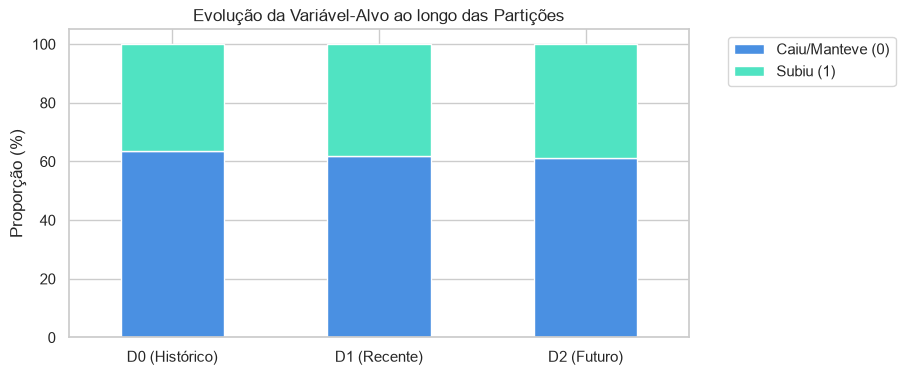

In [3]:
target_dist = pd.DataFrame({
    'D0 (Histórico)': d0['target_trend_up'].value_counts(normalize=True),
    'D1 (Recente)': d1['target_trend_up'].value_counts(normalize=True),
    'D2 (Futuro)': d2['target_trend_up'].value_counts(normalize=True)
}).T * 100

target_dist.columns = ['Caiu/Manteve (0)', 'Subiu (1)']
display(target_dist.round(2).astype(str) + '%')

target_dist.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#4A90E2', '#50E3C2'])
plt.title("Evolução da Variável-Alvo ao longo das Partições")
plt.ylabel("Proporção (%)")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()